# M.Tech Assignment - 04  
Wine Dataset
applies **Normalization** and **Standardization** on columns 1 to 3 of the Wine Dataset.

In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler
# Load the dataset
df = pd.read_csv('wine_data.csv')
df.head()

# Select columns 1 to 3
# (Python indexing starts from 0, so columns 1-3 means index 0 to 2)

cols = df.columns[0:3]

print("Selected Columns:")
print(cols)

Selected Columns:
Index(['1', '14.23', '1.71'], dtype='str')


In [3]:
# Apply Normalization using MinMaxScaler

minmax_scaler = MinMaxScaler()

normalized_data = minmax_scaler.fit_transform(df[cols])

normalized_df = pd.DataFrame(normalized_data, columns=cols)

print("Normalized Data:")
normalized_df.head()

Normalized Data:


,1,14.23,1.71
0,0.0,0.571053,0.205534
1,0.0,0.560526,0.320158
2,0.0,0.878947,0.239130
3,0.0,0.581579,0.365613
4,0.0,0.834211,0.201581


In [4]:
# Apply Standardization using StandardScaler

standard_scaler = StandardScaler()

standardized_data = standard_scaler.fit_transform(df[cols])

standardized_df = pd.DataFrame(standardized_data, columns=cols)

print("Standardized Data:")
standardized_df.head()

Standardized Data:


,1,14.23,1.71
0,-1.222468,0.255824,-0.501624
1,-1.222468,0.206229,0.018020
2,-1.222468,1.706501,-0.349315
3,-1.222468,0.305420,0.224086
4,-1.222468,1.495719,-0.519543


In [5]:
print("Original Data:")
print(df[cols].head())

print("\nNormalized Data:")
print(normalized_df.head())

print("\nStandardized Data:")
print(standardized_df.head())

Original Data:
   1  14.23  1.71
0  1  13.20  1.78
1  1  13.16  2.36
2  1  14.37  1.95
3  1  13.24  2.59
4  1  14.20  1.76

Normalized Data:
     1     14.23      1.71
0  0.0  0.571053  0.205534
1  0.0  0.560526  0.320158
2  0.0  0.878947  0.239130
3  0.0  0.581579  0.365613
4  0.0  0.834211  0.201581

Standardized Data:
          1     14.23      1.71
0 -1.222468  0.255824 -0.501624
1 -1.222468  0.206229  0.018020
2 -1.222468  1.706501 -0.349315
3 -1.222468  0.305420  0.224086
4 -1.222468  1.495719 -0.519543


# 2.Heart UCI Dataset
Identify categorical/discrete columns in the Heart UCI dataset and apply encoding techniques.

In [6]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
df = pd.read_csv('heart_disease_uci.csv')
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [7]:
categorical_cols = df.select_dtypes(include=['object']).columns

print("Categorical Columns:")
print(categorical_cols)

Categorical Columns:
Index(['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal'], dtype='str')


C:\Users\dadap\AppData\Local\Temp\ipykernel_17700\3301230942.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


In [8]:
# Apply Label Encoding to categorical columns

label_encoder = LabelEncoder()

encoded_df = df.copy()

for col in categorical_cols:
    encoded_df[col] = label_encoder.fit_transform(encoded_df[col].astype(str))

print("Encoded Dataset:")
encoded_df.head()

Encoded Dataset:


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,1,0,3,145.0,233.0,1,0,150.0,0,2.3,0,0.0,0,0
1,2,67,1,0,0,160.0,286.0,0,0,108.0,1,1.5,1,3.0,1,2
2,3,67,1,0,0,120.0,229.0,0,0,129.0,1,2.6,1,2.0,2,1
3,4,37,1,0,2,130.0,250.0,0,1,187.0,0,3.5,0,0.0,1,0
4,5,41,0,0,1,130.0,204.0,0,0,172.0,0,1.4,2,0.0,1,0


In [9]:
print("Original Dataset Sample:")
print(df[categorical_cols].head())

print("\nEncoded Dataset Sample:")
print(encoded_df[categorical_cols].head())

Original Dataset Sample:
      sex    dataset               cp    fbs         restecg  exang  \
0    Male  Cleveland   typical angina   True  lv hypertrophy  False   
1    Male  Cleveland     asymptomatic  False  lv hypertrophy   True   
2    Male  Cleveland     asymptomatic  False  lv hypertrophy   True   
3    Male  Cleveland      non-anginal  False          normal  False   
4  Female  Cleveland  atypical angina  False  lv hypertrophy  False   

         slope               thal  
0  downsloping       fixed defect  
1         flat             normal  
2         flat  reversable defect  
3  downsloping             normal  
4    upsloping             normal  

Encoded Dataset Sample:
   sex  dataset  cp  fbs  restecg  exang  slope  thal
0    1        0   3    1        0      0      0     0
1    1        0   0    0        0      1      1     1
2    1        0   0    0        0      1      1     2
3    1        0   2    0        1      0      0     1
4    0        0   1    0        0    

# 3 Weather AUS Dataset

## Objective
1. Find columns with missing values (NA)
2. Calculate ratio of missing values
3. Apply Mean, Median, and Mode imputation based on column type
4. Observe changes after imputation
5. Visualize missing values using simple plots

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv('weatherAUS.csv')

df.head()
print(df.info())


Matplotlib is building the font cache; this may take a moment.


<class 'pandas.DataFrame'>
RangeIndex: 142193 entries, 0 to 142192
Data columns (total 24 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           142193 non-null  str    
 1   Location       142193 non-null  str    
 2   MinTemp        141556 non-null  float64
 3   MaxTemp        141871 non-null  float64
 4   Rainfall       140787 non-null  float64
 5   Evaporation    81350 non-null   float64
 6   Sunshine       74377 non-null   float64
 7   WindGustDir    132863 non-null  str    
 8   WindGustSpeed  132923 non-null  float64
 9   WindDir9am     132180 non-null  str    
 10  WindDir3pm     138415 non-null  str    
 11  WindSpeed9am   140845 non-null  float64
 12  WindSpeed3pm   139563 non-null  float64
 13  Humidity9am    140419 non-null  float64
 14  Humidity3pm    138583 non-null  float64
 15  Pressure9am    128179 non-null  float64
 16  Pressure3pm    128212 non-null  float64
 17  Cloud9am       88536 non-null   float64


In [11]:
# Find missing values count

missing_values = df.isnull().sum()

# Display columns with missing values
missing_values = missing_values[missing_values > 0]

print("Columns with Missing Values:")
print(missing_values)


Columns with Missing Values:
MinTemp            637
MaxTemp            322
Rainfall          1406
Evaporation      60843
Sunshine         67816
WindGustDir       9330
WindGustSpeed     9270
WindDir9am       10013
WindDir3pm        3778
WindSpeed9am      1348
WindSpeed3pm      2630
Humidity9am       1774
Humidity3pm       3610
Pressure9am      14014
Pressure3pm      13981
Cloud9am         53657
Cloud3pm         57094
Temp9am            904
Temp3pm           2726
RainToday         1406
dtype: int64


In [12]:
# Calculate missing value ratio

missing_ratio = (df.isnull().sum() / len(df)) * 100

missing_ratio = missing_ratio[missing_ratio > 0]

print("Missing Value Ratio (%):")
print(missing_ratio.sort_values(ascending=False))

Missing Value Ratio (%):
Sunshine         47.692924
Evaporation      42.789026
Cloud3pm         40.152469
Cloud9am         37.735332
Pressure9am       9.855619
Pressure3pm       9.832411
WindDir9am        7.041838
WindGustDir       6.561504
WindGustSpeed     6.519308
WindDir3pm        2.656952
Humidity3pm       2.538803
Temp3pm           1.917113
WindSpeed3pm      1.849599
Humidity9am       1.247600
Rainfall          0.988797
RainToday         0.988797
WindSpeed9am      0.948007
Temp9am           0.635756
MinTemp           0.447983
MaxTemp           0.226453
dtype: float64


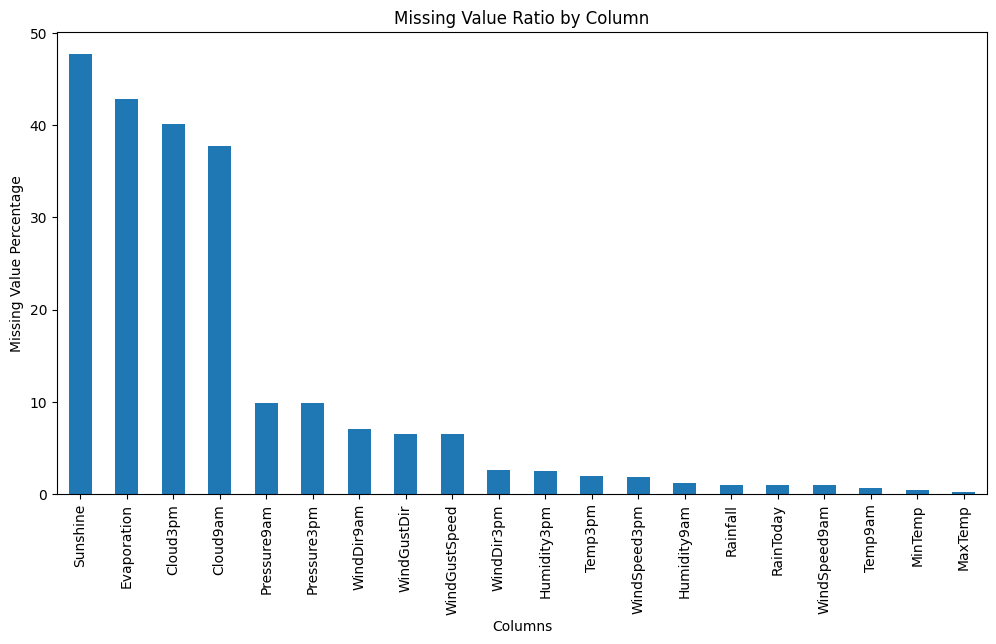

In [13]:
# Visualize missing values using bar plot

missing_ratio.sort_values(ascending=False).plot(
    kind='bar',
    figsize=(12,6)
)

plt.title('Missing Value Ratio by Column')
plt.xlabel('Columns')
plt.ylabel('Missing Value Percentage')
plt.xticks(rotation=90)

plt.show()

In [14]:
# Separate numerical and categorical columns

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

print("Numerical Columns:")
print(numerical_cols)

print("\nCategorical Columns:")
print(categorical_cols)

Numerical Columns:
Index(['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
       'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am',
       'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm',
       'Temp9am', 'Temp3pm', 'RISK_MM'],
      dtype='str')

Categorical Columns:
Index(['Date', 'Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm',
       'RainToday', 'RainTomorrow'],
      dtype='str')


C:\Users\dadap\AppData\Local\Temp\ipykernel_17700\1761443948.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


In [17]:
# Create copy of dataset for imputation
imputed_df = df.copy()

# Apply Mean Imputation for numerical columns
for col in numerical_cols:
    if imputed_df[col].isnull().sum() > 0:
        imputed_df[col].fillna(imputed_df[col].mean(), inplace=True)

print("Mean Imputation Completed")
# Apply Mode Imputation for categorical columns

for col in categorical_cols:
    if imputed_df[col].isnull().sum() > 0:
        imputed_df[col].fillna(imputed_df[col].mode()[0], inplace=True)

print("Mode Imputation Completed")

Mean Imputation Completed
Mode Imputation Completed


C:\Users\dadap\AppData\Local\Temp\ipykernel_17700\4157428582.py:7: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  imputed_df[col].fillna(imputed_df[col].mean(), inplace=True)
C:\Users\dadap\AppData\Local\Temp\ipykernel_17700\4157428582.py:14: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chain

In [18]:
# Check missing values after imputation

remaining_missing = imputed_df.isnull().sum()

remaining_missing = remaining_missing[remaining_missing > 0]

print("Remaining Missing Values After Imputation:")
print(remaining_missing)

Remaining Missing Values After Imputation:
MinTemp            637
MaxTemp            322
Rainfall          1406
Evaporation      60843
Sunshine         67816
WindGustDir       9330
WindGustSpeed     9270
WindDir9am       10013
WindDir3pm        3778
WindSpeed9am      1348
WindSpeed3pm      2630
Humidity9am       1774
Humidity3pm       3610
Pressure9am      14014
Pressure3pm      13981
Cloud9am         53657
Cloud3pm         57094
Temp9am            904
Temp3pm           2726
RainToday         1406
dtype: int64


In [20]:
# Example of Median Imputation on numerical columns

median_df = df.copy()

for col in numerical_cols:
    if median_df[col].isnull().sum() > 0:
        median_df[col].fillna(median_df[col].median(), inplace=True)

print("Median Imputation Completed")
# Compare missing values before and after imputation

print("Missing Values Before Imputation:")
print(df.isnull().sum().sum())

print("\nMissing Values After Mean/Mode Imputation:")
print(imputed_df.isnull().sum().sum())

print("\nMissing Values After Median Imputation:")
print(median_df.isnull().sum().sum())

C:\Users\dadap\AppData\Local\Temp\ipykernel_17700\2824492904.py:7: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  median_df[col].fillna(median_df[col].median(), inplace=True)
C:\Users\dadap\AppData\Local\Temp\ipykernel_17700\2824492904.py:7: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chaine

Median Imputation Completed
Missing Values Before Imputation:
316559

Missing Values After Mean/Mode Imputation:
316559

Missing Values After Median Imputation:
316559


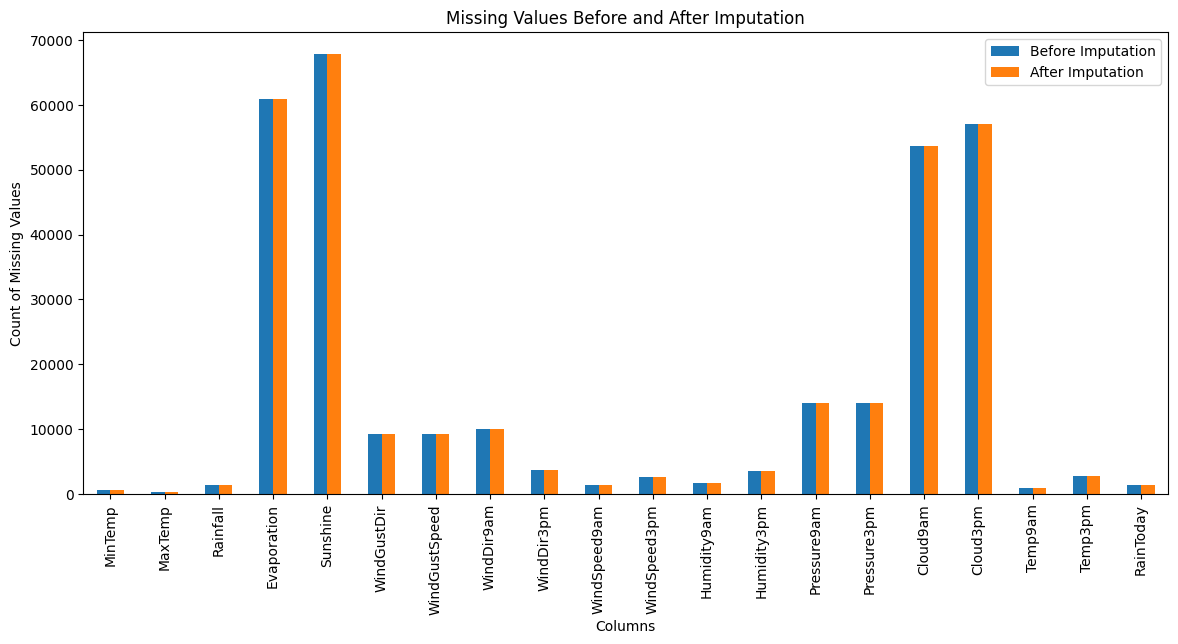

In [21]:
# Visualize missing values before and after imputation

comparison = pd.DataFrame({
    'Before Imputation': df.isnull().sum(),
    'After Imputation': imputed_df.isnull().sum()
})

comparison = comparison[comparison['Before Imputation'] > 0]

comparison.plot(
    kind='bar',
    figsize=(14,6)
)

plt.title('Missing Values Before and After Imputation')
plt.xlabel('Columns')
plt.ylabel('Count of Missing Values')
plt.xticks(rotation=90)

plt.show()